# Lab 4 — k-Nearest Neighbours: Palmer Penguins Classification

**What this lab covers:**
1. Load and explore the Palmer Penguins dataset
2. Why feature scaling is critical for kNN
3. Cross-validation to tune k
4. GridSearchCV as an alternative
5. Compare kNN and Logistic Regression
6. Final evaluation on a held-out test set

---

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline

np.random.seed(42)

## 1. Load and Explore the Data

In [2]:
df = pd.read_csv('penguins.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
df.info()
print(f"\nMissing values:\n{df.isnull().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


## 2. Data Preprocessing

We use 4 numerical features. Note the very different scales:
- Bill measurements: ~30–60 mm
- Flipper length: ~170–230 mm
- Body mass: ~2700–6300 g

kNN uses distance, so body_mass_g will completely dominate unless we scale.

In [4]:
# Drop rows with missing values
df_clean = df.dropna()

# Select features and target
feature_columns = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df_clean[feature_columns]
y = df_clean['species']

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Classes: {y.nunique()} — {list(y.unique())}")
print(f"\nClass distribution:\n{y.value_counts()}")

Samples: 333, Features: 4
Classes: 3 — ['Adelie', 'Gentoo', 'Chinstrap']

Class distribution:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


In [5]:
# Look at the feature ranges — this is why scaling matters
print(X.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000


## 3. Train/Test Split

In [6]:
# 80/20 split. Test set is held out until the very end.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training: {X_train.shape[0]}")
print(f"Test: {X_test.shape[0]}")

Training: 266
Test: 67


## 4. Cross-Validation

A single train/val split can be unreliable — results depend on which samples
land in each set. Cross-validation splits training data into K folds,
trains K times (each fold gets a turn as validation), and averages the scores.

```python
scores = cross_val_score(model, X_train, y_train, cv=5)
# Returns 5 accuracy scores, one per fold
```

## 5. kNN Without Scaling

In [7]:
knn_unscaled = KNeighborsClassifier(n_neighbors=5)

# 5-fold cross-validation on the training set
scores_unscaled = cross_val_score(knn_unscaled, X_train, y_train, cv=5)

print(f"CV scores (unscaled): {scores_unscaled}")
print(f"Mean: {scores_unscaled.mean():.3f} (+/- {scores_unscaled.std():.3f})")

CV scores (unscaled): [0.81481481 0.75471698 0.79245283 0.75471698 0.75471698]
Mean: 0.774 (+/- 0.025)


## 6. kNN With Scaling (Pipeline)

`make_pipeline` chains StandardScaler → KNeighborsClassifier.
When used with `cross_val_score`, the scaler is fit independently on each
fold's training portion — no data leakage.

In [8]:
knn_pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

scores_scaled = cross_val_score(knn_pipeline, X_train, y_train, cv=5)

print(f"CV scores (scaled): {scores_scaled}")
print(f"Mean: {scores_scaled.mean():.3f} (+/- {scores_scaled.std():.3f})")

CV scores (scaled): [0.98148148 0.98113208 0.98113208 0.96226415 0.96226415]
Mean: 0.974 (+/- 0.009)


In [9]:
print("=== Comparison ===")
print(f"Unscaled kNN: {scores_unscaled.mean():.3f} (+/- {scores_unscaled.std():.3f})")
print(f"Scaled kNN:   {scores_scaled.mean():.3f} (+/- {scores_scaled.std():.3f})")
print(f"Improvement:  {scores_scaled.mean() - scores_unscaled.mean():.3f}")

=== Comparison ===
Unscaled kNN: 0.774 (+/- 0.025)
Scaled kNN:   0.974 (+/- 0.009)
Improvement:  0.199


## 7. Hyperparameter Tuning — Finding the Best k

Try k=1 to k=20, evaluate each with cross-validation, pick the best.

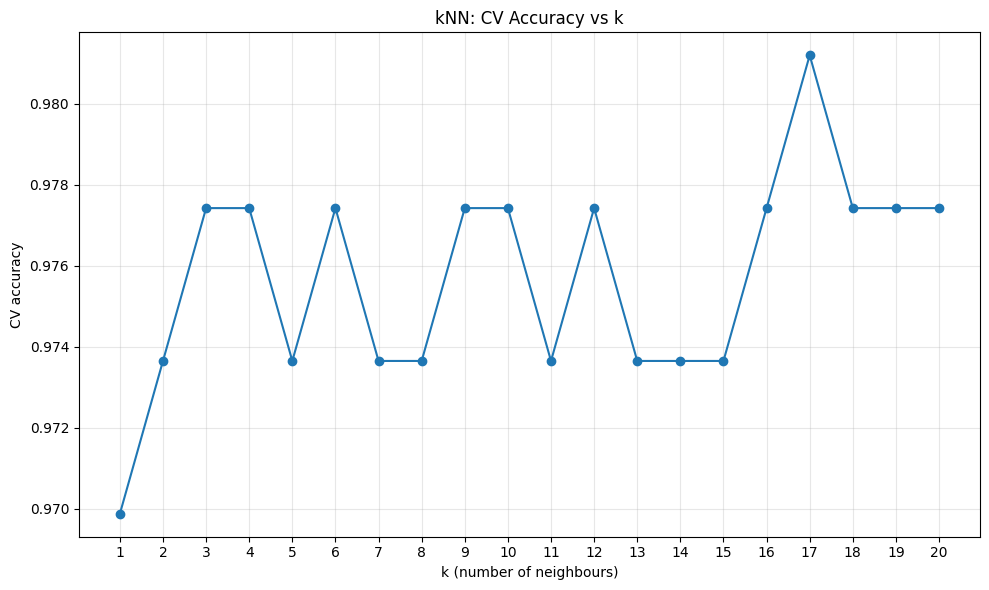

Best k: 17, CV accuracy: 0.981


In [10]:
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

# Plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('k (number of neighbours)')
plt.ylabel('CV accuracy')
plt.title('kNN: CV Accuracy vs k')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k: {best_k}, CV accuracy: {max(cv_scores):.3f}")

### Alternative: GridSearchCV

GridSearchCV automates the loop above. For pipeline parameters,
use the syntax `stepname__parametername`.

In [11]:
pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier())

# Parameter name format: lowercase class name + __ + parameter
param_grid = {'kneighborsclassifier__n_neighbors': range(1, 21)}

grid_search = GridSearchCV(pipeline, param_grid, cv=5)
grid_search.fit(X_train, y_train)

print(f"Best k (GridSearchCV): {grid_search.best_params_['kneighborsclassifier__n_neighbors']}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")

Best k (GridSearchCV): 17
Best CV accuracy: 0.981


## 8. Logistic Regression — Tune C and Compare

Same approach: pipeline with scaling, cross-validation, tune C.

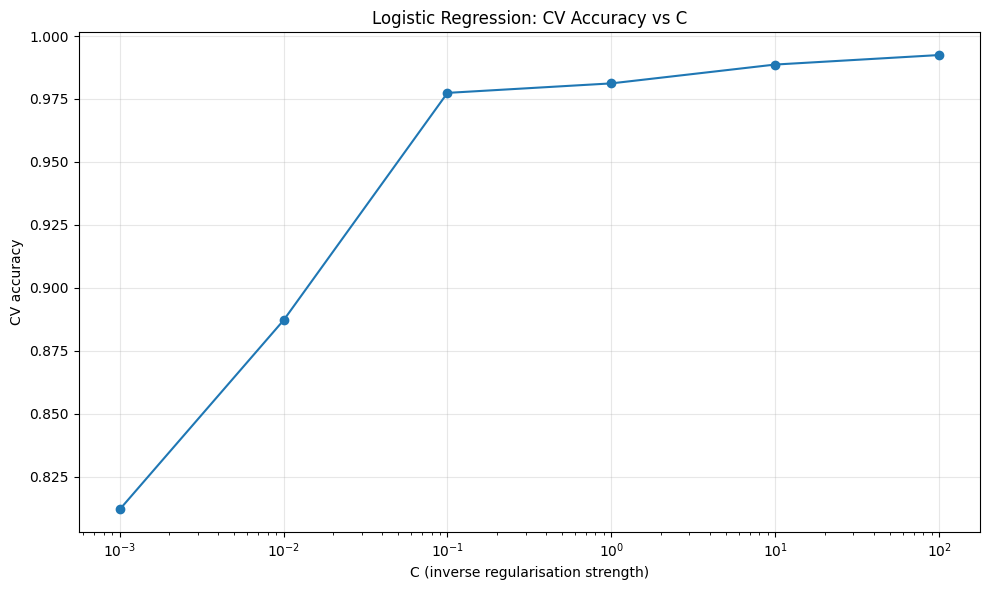

Best C: 100, CV accuracy: 0.992


In [12]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
lr_scores = []

for C in C_values:
    pipeline = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=1000))
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    lr_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.semilogx(C_values, lr_scores, marker='o')
plt.xlabel('C (inverse regularisation strength)')
plt.ylabel('CV accuracy')
plt.title('Logistic Regression: CV Accuracy vs C')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_C = C_values[np.argmax(lr_scores)]
print(f"Best C: {best_C}, CV accuracy: {max(lr_scores):.3f}")

## 9. Model Comparison

In [13]:
# Build final pipelines with best hyperparameters
final_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
final_lr = make_pipeline(StandardScaler(), LogisticRegression(C=best_C, max_iter=1000))

knn_cv_scores = cross_val_score(final_knn, X_train, y_train, cv=5)
lr_cv_scores = cross_val_score(final_lr, X_train, y_train, cv=5)

print("=== Model Comparison (Cross-Validation) ===")
print(f"kNN (k={best_k}):     {knn_cv_scores.mean():.3f} (+/- {knn_cv_scores.std():.3f})")
print(f"LogReg (C={best_C}):  {lr_cv_scores.mean():.3f} (+/- {lr_cv_scores.std():.3f})")

=== Model Comparison (Cross-Validation) ===
kNN (k=17):     0.981 (+/- 0.012)
LogReg (C=100):  0.992 (+/- 0.009)


/tmp/ipykernel_42511/3876110530.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([knn_cv_scores, lr_cv_scores], labels=['kNN', 'Logistic Regression'])


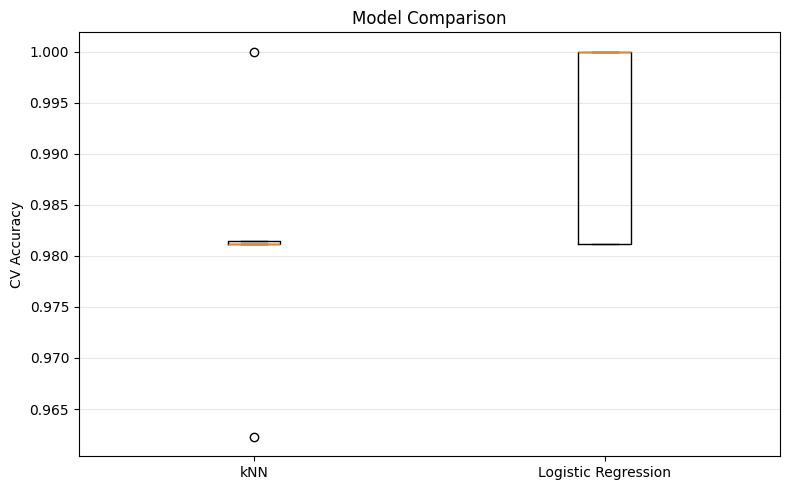

In [14]:
# Box plot comparison
plt.figure(figsize=(8, 5))
plt.boxplot([knn_cv_scores, lr_cv_scores], labels=['kNN', 'Logistic Regression'])
plt.ylabel('CV Accuracy')
plt.title('Model Comparison')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Final Evaluation on Test Set

Pick the model with the better CV score, train on full training set,
evaluate once on the held-out test set.

In [15]:
# Pick whichever performed better in CV
final_model = final_knn  # or final_lr

# Train on full training set
final_model.fit(X_train, y_train)

# Predict on test set
y_pred = final_model.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.970

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.94      1.00      0.97        31
   Chinstrap       1.00      0.89      0.94        18
      Gentoo       1.00      1.00      1.00        18

    accuracy                           0.97        67
   macro avg       0.98      0.96      0.97        67
weighted avg       0.97      0.97      0.97        67



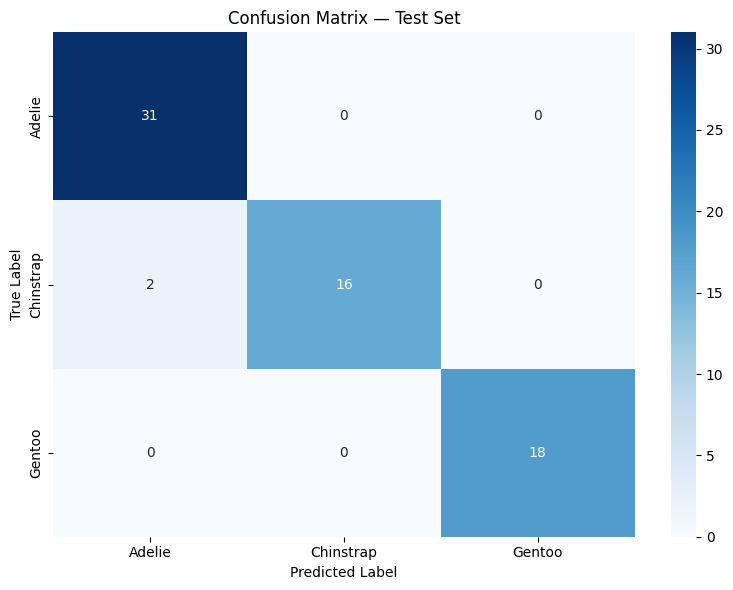

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_model.classes_,
            yticklabels=final_model.classes_)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

---
## Bonus: Adding Categorical Features

The dataset also has island and sex. We one-hot encode them
(`pd.get_dummies`) to convert categories into binary columns.

In [17]:
df_with_cat = pd.read_csv('penguins.csv').dropna()

X_with_cat = df_with_cat[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
                           'body_mass_g', 'island', 'sex']]

# One-hot encode: creates binary columns for each category
X_encoded = pd.get_dummies(X_with_cat, drop_first=True)
y_with_cat = df_with_cat['species']

print(f"Before encoding: {X_with_cat.shape[1]} columns")
print(f"After encoding: {X_encoded.shape[1]} columns")
print(f"Columns: {list(X_encoded.columns)}")

Before encoding: 6 columns
After encoding: 7 columns
Columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_male']


In [18]:
# Split
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_encoded, y_with_cat, test_size=0.2, random_state=42
)

# kNN with categorical features
knn_with_cat = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
scores_with_cat = cross_val_score(knn_with_cat, X_train_cat, y_train_cat, cv=5)

print(f"kNN + categorical: {scores_with_cat.mean():.3f} (+/- {scores_with_cat.std():.3f})")
print(f"kNN numerical only: {knn_cv_scores.mean():.3f} (+/- {knn_cv_scores.std():.3f})")
print(f"Difference: {scores_with_cat.mean() - knn_cv_scores.mean():+.3f}")

kNN + categorical: 0.993 (+/- 0.009)
kNN numerical only: 0.981 (+/- 0.012)
Difference: +0.011


In [19]:
# Logistic Regression with categorical features
lr_with_cat = make_pipeline(StandardScaler(), LogisticRegression(C=best_C, max_iter=1000))
scores_lr_cat = cross_val_score(lr_with_cat, X_train_cat, y_train_cat, cv=5)

print(f"LogReg + categorical: {scores_lr_cat.mean():.3f} (+/- {scores_lr_cat.std():.3f})")
print(f"LogReg numerical only: {lr_cv_scores.mean():.3f} (+/- {lr_cv_scores.std():.3f})")
print(f"Difference: {scores_lr_cat.mean() - lr_cv_scores.mean():+.3f}")

LogReg + categorical: 0.992 (+/- 0.009)
LogReg numerical only: 0.992 (+/- 0.009)
Difference: +0.000


---
## Summary

### kNN
```python
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Always scale for kNN
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))

# Cross-validation to find best k
scores = cross_val_score(pipe, X_train, y_train, cv=5)
```

### Why scaling is mandatory for kNN
kNN classifies by distance to nearest neighbours. Features with larger ranges
(e.g. body mass in grams) dominate the distance calculation and make smaller-range
features (e.g. bill depth in mm) irrelevant. StandardScaler fixes this.

### Why Pipeline matters
If you scale before splitting into folds, validation fold statistics leak into
training. A pipeline scales inside each fold independently — no leakage.

### cross_val_score vs GridSearchCV
- `cross_val_score`: you write the loop, call it once per hyperparameter config
- `GridSearchCV`: you give it a parameter grid, it tries all combos automatically
- Both do the same thing, GridSearchCV is just more convenient

### kNN vs Logistic Regression
| | kNN | Logistic Regression |
|---|---|---|
| Scaling needed? | Yes (mandatory) | Yes (helps convergence) |
| Hyperparameter | k (neighbours) | C (regularisation) |
| Interpretable? | No | Yes (coefficients) |
| Decision boundary | Non-linear | Linear |
| Slow at prediction? | Yes (compares to all training points) | No |